# 3. Featurize (horizon stacking)

The mart gives one row per hour per region, with features already computed as of that hour. That's not yet a training set, because we want to predict a **24-hour curve**, not one number -- and LightGBM only ever predicts one number per row it's given.

The fix: duplicate every row 24 times, once per forecast horizon `h = 1..24`, and attach two new columns to each copy:

- `target_mwh` -- the *actual* demand at `t + h` (what we're predicting)
- `baseline_mwh` -- EIA's own forecast for `t + h` (what we're trying to beat)
- `horizon` -- `h` itself, fed in as just another input feature

So the model learns one function: "given features as of hour t, and how far out you're asking, predict demand." Ask it 24 times with the same row and `horizon = 1..24` and you get a full curve. See `src/ml/dataset.py::stack_horizons` for the actual join logic (matched by timestamp, not row position, so a missing hour anywhere in a region's series can't silently mislabel a row).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from src.ml.dataset import FEATURE_COLUMNS, stack_horizons

params = yaml.safe_load(open(PROJECT_ROOT / "params.yaml"))["featurize"]
params

{'horizons': 24}

In [3]:
clean_path = PROJECT_ROOT / "data" / "interim" / "features_clean.csv"
df = pd.read_csv(clean_path, parse_dates=["demand_hour_utc"])

stacked = stack_horizons(df, range(1, params["horizons"] + 1))
print(f"{len(df):,} rows -> {len(stacked):,} rows after stacking "
      f"({params['horizons']} horizons)")

131,402 rows -> 3,152,724 rows after stacking (24 horizons)


### Sanity check: every horizon should have roughly the same row count

Higher horizons lose a few more rows at the very end of each region's series (there's no `t + 24` for the last day of data), so a slight downward slope is expected -- a cliff would mean something's wrong with the join.

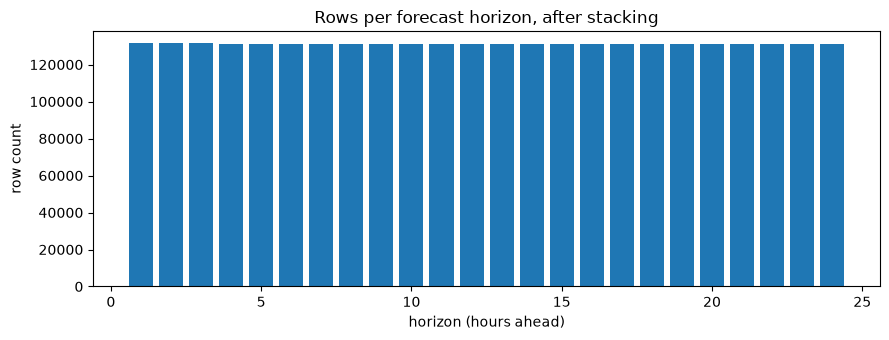

In [4]:
counts = stacked.groupby("horizon").size()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(counts.index, counts.values)
ax.set_xlabel("horizon (hours ahead)")
ax.set_ylabel("row count")
ax.set_title("Rows per forecast horizon, after stacking")
fig.tight_layout()
plt.show()

In [5]:
before = len(stacked)
stacked = stacked.dropna(subset=[*FEATURE_COLUMNS, "target_mwh", "baseline_mwh"])
print(f"dropped {before - len(stacked):,} rows with missing features/target/baseline "
      f"(mostly each region's first ~168h warm-up period)")

dropped 25,313 rows with missing features/target/baseline (mostly each region's first ~168h warm-up period)


In [6]:
out_path = PROJECT_ROOT / "data" / "processed" / "train_frame.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
stacked.to_csv(out_path, index=False)
print(f"wrote {out_path} ({len(stacked):,} rows)")

wrote /Users/devashish/Desktop/Projects/gridcast/data/processed/train_frame.csv (3,127,411 rows)
